In [19]:
import pandas as pd

df = pd.read_csv('Clean_dataset.csv')

In [20]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [21]:
df.airline.value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

In [22]:
df.source_city.value_counts()

source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

In [23]:
df.destination_city.value_counts()

destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad    42726
Chennai      40368
Name: count, dtype: int64

In [24]:
df.departure_time.value_counts()

departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

In [25]:
df.arrival_time.value_counts()

arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Late_Night       14001
Name: count, dtype: int64

In [26]:
df.stops.value_counts()

stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

In [27]:
df['class'].value_counts()

class
Economy     206666
Business     93487
Name: count, dtype: int64

In [28]:
df['duration'].min()

np.float64(0.83)

In [29]:
df['duration'].max()

np.float64(49.83)

In [30]:
df['duration'].median()

np.float64(11.25)

## Preprocessing

In [31]:
df = df.drop(['Unnamed: 0'], axis=1)    
df = df.drop(['flight'], axis=1)

df['class'] = df['class'].apply(lambda x: 1 if x == 'Business' else 0)


In [32]:
df.stops = pd.factorize(df.stops)[0]

In [33]:
df = df.join(pd.get_dummies(df.airline, prefix='airline')).drop('airline', axis=1)
df = df.join(pd.get_dummies(df.source_city, prefix='source_city')).drop('source_city', axis=1)
df = df.join(pd.get_dummies(df.destination_city, prefix='destination_city')).drop('destination_city', axis=1)
df = df.join(pd.get_dummies(df.arrival_time, prefix='arrival_time')).drop('arrival_time', axis=1)
df = df.join(pd.get_dummies(df.departure_time, prefix='departure_time')).drop('departure_time', axis=1)

df

,stops,class,duration,days_left,price,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,departure_time_Afternoon,departure_time_Early_Morning,departure_time_Evening,departure_time_Late_Night,departure_time_Morning,departure_time_Night
0,0,0,2.17,1,5953,False,False,False,False,True,...,False,False,False,True,False,False,True,False,False,False
1,0,0,2.33,1,5953,False,False,False,False,True,...,False,False,True,False,False,True,False,False,False,False
2,0,0,2.17,1,5956,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,0,0,2.25,1,5955,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,0,0,2.33,1,5955,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,1,1,10.08,49,69265,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
300149,1,1,10.42,49,77105,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
300150,1,1,13.83,49,79099,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
300151,1,1,10.00,49,81585,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False


## Training Regression Model

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X, y = df.drop('price', axis=1), df.price

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [37]:
reg = RandomForestRegressor(n_jobs=-1)

reg.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1)

In [38]:
reg.score(X_test, y_test)

0.9855612433218756

In [39]:
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = reg.predict(X_test)

print('R2:' + str(r2_score(y_test, y_pred)))
print('MAE:' + str(mean_absolute_error(y_test, y_pred)))
print('MSE:' + str(mean_squared_error(y_test, y_pred)))
print('RMSE:' + str(math.sqrt(mean_squared_error(y_test, y_pred))))

R2:0.9855612433218756
MAE:1069.6383054208368
MSE:7413700.937030081
RMSE:2722.8112194990827


Text(0.5, 1.0, 'Prediction VS Actual Price')

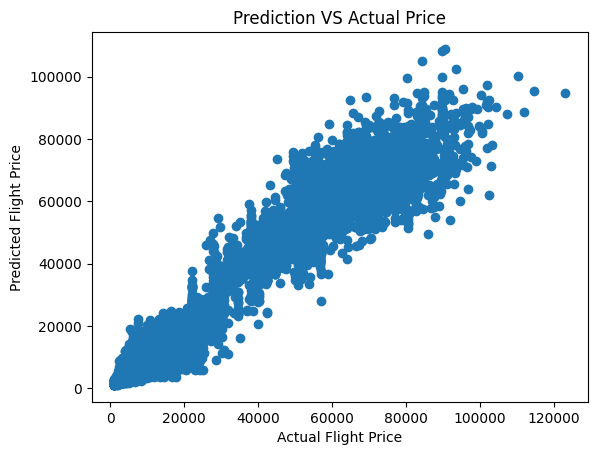

In [40]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel('Actual Flight Price')
plt.ylabel('Predicted Flight Price')
plt.title('Prediction VS Actual Price')

In [41]:
df.price.describe()

count    300153.000000
mean      20889.660523
std       22697.767366
min        1105.000000
25%        4783.000000
50%        7425.000000
75%       42521.000000
max      123071.000000
Name: price, dtype: float64

In [42]:
importances = dict(zip(reg.feature_names_in_, reg.feature_importances_))
sorted_importances = sorted(importances.items(), key=lambda x: x[1], reverse=True)

sorted_importances

[('class', np.float64(0.8800680534829768)),
 ('duration', np.float64(0.05712648041332834)),
 ('days_left', np.float64(0.01870558040487005)),
 ('airline_Air_India', np.float64(0.005585254943112867)),
 ('airline_Vistara', np.float64(0.004381359599772084)),
 ('source_city_Delhi', np.float64(0.003554538271553354)),
 ('destination_city_Delhi', np.float64(0.0032135441376489613)),
 ('source_city_Mumbai', np.float64(0.0023163773928356036)),
 ('stops', np.float64(0.0019414109638229379)),
 ('destination_city_Mumbai', np.float64(0.0019341518117196672)),
 ('destination_city_Kolkata', np.float64(0.0018758028231413298)),
 ('source_city_Kolkata', np.float64(0.001727526447902451)),
 ('arrival_time_Evening', np.float64(0.001580787026624362)),
 ('destination_city_Hyderabad', np.float64(0.0015100844440488815)),
 ('destination_city_Bangalore', np.float64(0.001316725465747967)),
 ('source_city_Hyderabad', np.float64(0.0012368435469797998)),
 ('arrival_time_Night', np.float64(0.0012104268072229746)),
 ('sou

<BarContainer object of 10 artists>

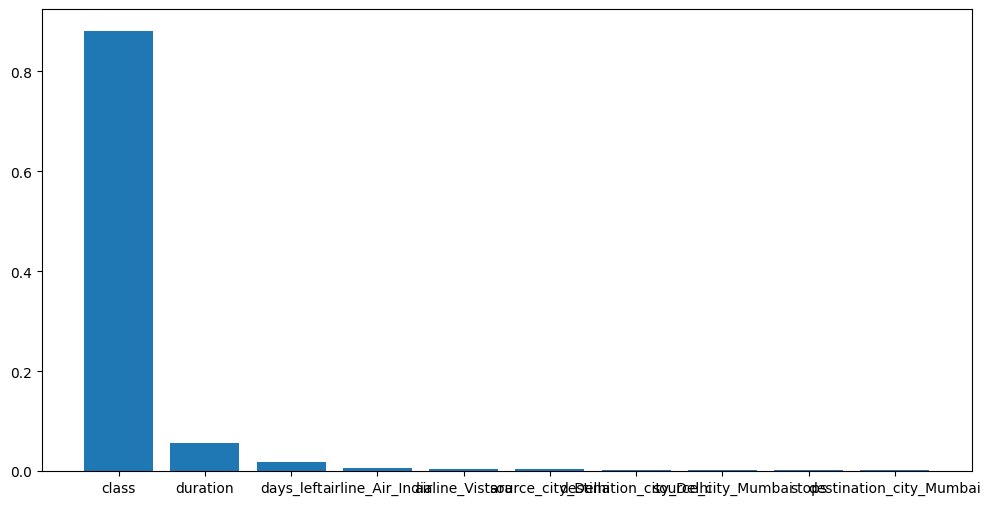

In [43]:
plt.figure(figsize=(12, 6))
plt.bar([x[0] for x in sorted_importances[:10]], [x[1] for x in sorted_importances[:10]])

## Hyperparameter

In [ ]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_absolute_error

# param_grid = {
#     "n_estimators": [100, 200],
#     "max_depth": [None, 20],
#     "min_samples_split": [2, 5],
#     "min_samples_leaf": [1, 2],
#     "max_features": ["sqrt", 1.0],
# }

# grid_search = GridSearchCV(
#     estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
#     param_grid=param_grid,
#     scoring="neg_mean_absolute_error",
#     cv=3,
#     n_jobs=1,
#     verbose=2,
# )

# grid_search.fit(X_train, y_train)

# print("Best parameters:", grid_search.best_params_)
# print("Best CV MAE:", -grid_search.best_score_)

# best_model = grid_search.best_estimator_
# y_pred = best_model.predict(X_test)
# print("Test MAE:", mean_absolute_error(y_test, y_pred))

# #après 1h30 j'ai arrêté de faire tourner ça devenait long mais bon je suis motivé...
# #s'il vous plait embauchez moi que je puisse m'acheter un nouveau pc pour faire tourner ça plus vite

Fitting 3 folds for each of 32 candidates, totalling 96 fits
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  31.9s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  21.6s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  20.7s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  47.6s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  45.1s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  42.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  20.7s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, 

KeyboardInterrupt: 

In [47]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': [1.0, 'sqrt']
}

reg = RandomForestRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(estimator=reg, param_distributions=param_dist, n_iter=2, cv=3,
                                   scoring='neg_mean_squared_error', verbose=2, random_state=42, n_jobs=-1)

random_search.fit(X_train, y_train)

best_regressor = random_search.best_estimator_

Fitting 3 folds for each of 2 candidates, totalling 6 fits


In [48]:
best_regressor.score(X_test, y_test)

0.9865683061237944

In [50]:
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = best_regressor.predict(X_test)

print('R2:' + str(r2_score(y_test, y_pred)))
print('MAE:' + str(mean_absolute_error(y_test, y_pred)))
print('MSE:' + str(mean_squared_error(y_test, y_pred)))
print('RMSE:' + str(math.sqrt(mean_squared_error(y_test, y_pred))))

R2:0.9865683061237944
MAE:1108.2201633291065
MSE:6896616.079609845
RMSE:2626.1409100826722


Text(0.5, 1.0, 'Prediction VS Actual Price')

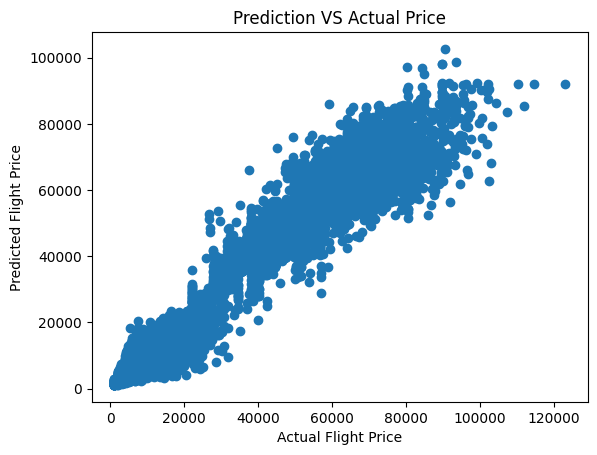

In [51]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel('Actual Flight Price')
plt.ylabel('Predicted Flight Price')
plt.title('Prediction VS Actual Price')